# Emotion Classification: CNN vs Random Forest
Train separate binary classifiers for each emotion (Boredom, Engagement, Confusion, Frustration) using 3_Changepoint engineered data with custom thresholds and SMOTE resampling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.12.1


In [2]:
# Configuration
DATA_PATH = 'Data/Engineered/3_Changepoint'
TRAIN_FILE = f'{DATA_PATH}/3_Changepoint_Train.csv'
TEST_FILE = f'{DATA_PATH}/3_Changepoint_Test.csv'
VAL_FILE = f'{DATA_PATH}/3_Changepoint_Validation.csv'

# Emotion binary thresholds
EMOTION_THRESHOLDS = {
    'Engagement_first': 3,
    'Boredom_first': 1,
    'Confusion_first': 1,
    'Frustration_first': 1
}

# Model hyperparameters
CNN_EPOCHS = 100
CNN_BATCH_SIZE = 32
CNN_VALIDATION_SPLIT = 0.2
CNN_EARLY_STOPPING_PATIENCE = 15

RF_N_ESTIMATORS = 100
RF_RANDOM_STATE = 42
CNN_RANDOM_STATE = 42

# Set random seeds for reproducibility
np.random.seed(CNN_RANDOM_STATE)
tf.random.set_seed(CNN_RANDOM_STATE)

print("Configuration loaded successfully")

Configuration loaded successfully


In [3]:
# Load data
print("Loading datasets...")
df_train = pd.read_csv(TRAIN_FILE)
df_test = pd.read_csv(TEST_FILE)
df_val = pd.read_csv(VAL_FILE)

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"\nTrain columns sample: {df_train.columns.tolist()[:10]}")
print(f"Total features: {len(df_train.columns)}")

Loading datasets...
Train shape: (5437, 342)
Test shape: (1831, 342)
Validation shape: (1684, 342)

Train columns sample: ['source_video_path', 'gaze_0_x_mean', 'gaze_0_x_std', 'gaze_0_x_max', 'gaze_0_x_min', 'gaze_0_y_mean', 'gaze_0_y_std', 'gaze_0_y_max', 'gaze_0_y_min', 'gaze_0_z_mean']
Total features: 342


In [4]:
# Extract features and remove non-feature columns
columns_to_drop = ['source_video_path', 'person_id_first']
feature_columns = [col for col in df_train.columns if col not in columns_to_drop and col not in EMOTION_THRESHOLDS.keys()]

X_train = df_train[feature_columns].values
X_test = df_test[feature_columns].values
X_val = df_val[feature_columns].values

print(f"Feature matrix shape (train): {X_train.shape}")
print(f"Features used: {len(feature_columns)}")

# Create binary labels with custom thresholds
def create_binary_labels(df, emotion, threshold):
    """Convert emotion scores to binary labels using threshold"""
    return (df[emotion] >= threshold).astype(int).values

print("\n" + "="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)

emotion_data = {}
for emotion, threshold in EMOTION_THRESHOLDS.items():
    y_train = create_binary_labels(df_train, emotion, threshold)
    y_test = create_binary_labels(df_test, emotion, threshold)
    y_val = create_binary_labels(df_val, emotion, threshold)
    
    emotion_data[emotion] = {
        'y_train': y_train,
        'y_test': y_test,
        'y_val': y_val,
        'threshold': threshold
    }
    
    print(f"\n{emotion} (threshold={threshold}):")
    print(f"  Train - Class 0: {np.sum(y_train==0):4d} ({100*np.sum(y_train==0)/len(y_train):.1f}%), Class 1: {np.sum(y_train==1):4d} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")
    print(f"  Test  - Class 0: {np.sum(y_test==0):4d} ({100*np.sum(y_test==0)/len(y_test):.1f}%), Class 1: {np.sum(y_test==1):4d} ({100*np.sum(y_test==1)/len(y_test):.1f}%)")
    print(f"  Val   - Class 0: {np.sum(y_val==0):4d} ({100*np.sum(y_val==0)/len(y_val):.1f}%), Class 1: {np.sum(y_val==1):4d} ({100*np.sum(y_val==1)/len(y_val):.1f}%)")

Feature matrix shape (train): (5437, 336)
Features used: 336

CLASS DISTRIBUTION ANALYSIS

Engagement_first (threshold=3):
  Train - Class 0: 2866 (52.7%), Class 1: 2571 (47.3%)
  Test  - Class 0: 1065 (58.2%), Class 1:  766 (41.8%)
  Val   - Class 0: 1066 (63.3%), Class 1:  618 (36.7%)

Boredom_first (threshold=1):
  Train - Class 0: 2474 (45.5%), Class 1: 2963 (54.5%)
  Test  - Class 0:  934 (51.0%), Class 1:  897 (49.0%)
  Val   - Class 0:  526 (31.2%), Class 1: 1158 (68.8%)

Confusion_first (threshold=1):
  Train - Class 0: 3662 (67.4%), Class 1: 1775 (32.6%)
  Test  - Class 0: 1292 (70.6%), Class 1:  539 (29.4%)
  Val   - Class 0: 1074 (63.8%), Class 1:  610 (36.2%)

Frustration_first (threshold=1):
  Train - Class 0: 4252 (78.2%), Class 1: 1185 (21.8%)
  Test  - Class 0: 1466 (80.1%), Class 1:  365 (19.9%)
  Val   - Class 0: 1235 (73.3%), Class 1:  449 (26.7%)


In [5]:
# Standardize features
print("\nScaling features with StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print(f"Scaled train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Scaled test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")
print("Features scaled successfully")


Scaling features with StandardScaler...
Scaled train mean: 0.000000, std: 0.957427
Scaled test mean: 0.033754, std: 1.005609
Features scaled successfully


In [6]:
# Apply SMOTE to training data for each emotion
print("\n" + "="*60)
print("APPLYING SMOTE TO TRAINING DATA")
print("="*60)

for emotion in EMOTION_THRESHOLDS.keys():
    y_train = emotion_data[emotion]['y_train']
    
    print(f"\n{emotion}:")
    print(f"  Before SMOTE - Class 0: {np.sum(y_train==0)}, Class 1: {np.sum(y_train==1)}")
    
    smote = SMOTE(random_state=CNN_RANDOM_STATE)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    
    emotion_data[emotion]['X_train_smote'] = X_train_smote
    emotion_data[emotion]['y_train_smote'] = y_train_smote
    
    print(f"  After SMOTE  - Class 0: {np.sum(y_train_smote==0)}, Class 1: {np.sum(y_train_smote==1)}")
    print(f"  Training set size increased from {len(y_train)} to {len(y_train_smote)} ({100*len(y_train_smote)/len(y_train):.1f}%)")

print("\nSMOTE applied successfully to all emotions")


APPLYING SMOTE TO TRAINING DATA

Engagement_first:
  Before SMOTE - Class 0: 2866, Class 1: 2571
  After SMOTE  - Class 0: 2866, Class 1: 2866
  Training set size increased from 5437 to 5732 (105.4%)

Boredom_first:
  Before SMOTE - Class 0: 2474, Class 1: 2963
  After SMOTE  - Class 0: 2963, Class 1: 2963
  Training set size increased from 5437 to 5926 (109.0%)

Confusion_first:
  Before SMOTE - Class 0: 3662, Class 1: 1775
  After SMOTE  - Class 0: 3662, Class 1: 3662
  Training set size increased from 5437 to 7324 (134.7%)

Frustration_first:
  Before SMOTE - Class 0: 4252, Class 1: 1185
  After SMOTE  - Class 0: 4252, Class 1: 4252
  Training set size increased from 5437 to 8504 (156.4%)

SMOTE applied successfully to all emotions


In [7]:
def build_cnn_model(input_shape):
    """Build a 1D CNN model for binary classification
    
    Flattens input features into a 1D sequence for Conv1D layers.
    Input shape should be (num_samples, num_features)
    """
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        # Reshape flat features into (features, 1) for Conv1D
        layers.Reshape((input_shape, 1)),
        # First Conv1D block - processes the feature sequence
        layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        # Second Conv1D block
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        # Third Conv1D block
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        # Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Test model building
test_model = build_cnn_model(input_shape=X_train_scaled.shape[1])
print(f"\nCNN Model Architecture:")
test_model.summary()


CNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 336, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 336, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 168, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 168, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 84, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 84, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 84, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       688,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,617 (2.78 MB)

 Trainable params: 727,617 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def train_cnn(X_train, y_train, X_val, y_val, emotion_name):
    """Train CNN model with early stopping"""
    model = build_cnn_model(input_shape=X_train.shape[1])
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CNN_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CNN_EPOCHS,
        batch_size=CNN_BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=0
    )
    
    return model, history

def train_random_forest(X_train, y_train):
    """Train Random Forest baseline"""
    rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RF_RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    rf.fit(X_train, y_train)
    return rf

def evaluate_models(cnn_model, rf_model, X_test, y_test, emotion_name):
    """Evaluate both models and compute metrics"""
    metrics = {}
    
    # CNN predictions
    cnn_pred_proba = cnn_model.predict(X_test, verbose=0).flatten()
    cnn_pred = (cnn_pred_proba >= 0.5).astype(int)
    
    # Random Forest predictions
    rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
    rf_pred = rf_model.predict(X_test)
    
    # Compute metrics for both models
    for model_name, pred, pred_proba in [('CNN', cnn_pred, cnn_pred_proba), 
                                          ('RandomForest', rf_pred, rf_pred_proba)]:
        metrics[model_name] = {
            'accuracy': accuracy_score(y_test, pred),
            'precision': precision_score(y_test, pred, zero_division=0),
            'recall': recall_score(y_test, pred, zero_division=0),
            'f1': f1_score(y_test, pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, pred_proba),
            'confusion_matrix': confusion_matrix(y_test, pred),
            'predictions': pred,
            'predictions_proba': pred_proba
        }
    
    return metrics

print("Model training and evaluation functions defined")

Model training and evaluation functions defined


In [9]:
# Training loop for all emotions
print("\n" + "="*60)
print("TRAINING MODELS FOR ALL EMOTIONS")
print("="*60)

trained_models = {}
all_results = []

for emotion in EMOTION_THRESHOLDS.keys():
    print(f"\n{'='*60}")
    print(f"Training for: {emotion}")
    print(f"{'='*60}")
    
    # Get SMOTE-balanced training data
    X_train_emotion = emotion_data[emotion]['X_train_smote']
    y_train_emotion = emotion_data[emotion]['y_train_smote']
    y_test_emotion = emotion_data[emotion]['y_test']
    y_val_emotion = emotion_data[emotion]['y_val']
    
    trained_models[emotion] = {}
    
    # Train CNN
    print(f"\nTraining CNN for {emotion}...")
    cnn_model, cnn_history = train_cnn(
        X_train_emotion, y_train_emotion,
        X_val_scaled, y_val_emotion,
        emotion
    )
    trained_models[emotion]['cnn_model'] = cnn_model
    trained_models[emotion]['cnn_history'] = cnn_history
    print(f"CNN training complete (converged at epoch {len(cnn_history.history['loss'])})")
    
    # Train Random Forest
    print(f"Training Random Forest for {emotion}...")
    rf_model = train_random_forest(X_train_emotion, y_train_emotion)
    trained_models[emotion]['rf_model'] = rf_model
    print(f"Random Forest training complete")
    
    # Evaluate on test set
    print(f"\nEvaluating on test set...")
    metrics = evaluate_models(cnn_model, rf_model, X_test_scaled, y_test_emotion, emotion)
    trained_models[emotion]['metrics'] = metrics
    
    # Store results for comparison
    for model_name, model_metrics in metrics.items():
        result = {
            'emotion': emotion,
            'model': model_name,
            'accuracy': model_metrics['accuracy'],
            'precision': model_metrics['precision'],
            'recall': model_metrics['recall'],
            'f1': model_metrics['f1'],
            'roc_auc': model_metrics['roc_auc']
        }
        all_results.append(result)
        print(f"  {model_name}: Acc={model_metrics['accuracy']:.4f}, Prec={model_metrics['precision']:.4f}, Rec={model_metrics['recall']:.4f}, F1={model_metrics['f1']:.4f}, AUC={model_metrics['roc_auc']:.4f}")

print("\n" + "="*60)
print("ALL TRAINING COMPLETE")
print("="*60)


TRAINING MODELS FOR ALL EMOTIONS

Training for: Engagement_first

Training CNN for Engagement_first...
CNN training complete (converged at epoch 16)
Training Random Forest for Engagement_first...
Random Forest training complete

Evaluating on test set...
  CNN: Acc=0.4675, Prec=0.4238, Rec=0.7585, F1=0.5438, AUC=0.5090
  RandomForest: Acc=0.5636, Prec=0.4807, Rec=0.5366, F1=0.5071, AUC=0.5717

Training for: Boredom_first

Training CNN for Boredom_first...
CNN training complete (converged at epoch 19)
Training Random Forest for Boredom_first...
Random Forest training complete

Evaluating on test set...
  CNN: Acc=0.5532, Prec=0.5770, Rec=0.3300, F1=0.4199, AUC=0.5975
  RandomForest: Acc=0.5478, Prec=0.5377, Rec=0.5485, F1=0.5430, AUC=0.5638

Training for: Confusion_first

Training CNN for Confusion_first...
CNN training complete (converged at epoch 16)
Training Random Forest for Confusion_first...
Random Forest training complete

Evaluating on test set...
  CNN: Acc=0.6472, Prec=0.3770

In [10]:
# Create results DataFrame for comparison
results_df = pd.DataFrame(all_results)

print("\n" + "="*60)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*60)
print("\n" + results_df.to_string(index=False))

# Create pivot table for easier comparison
print("\n\nPivot by Model and Metric:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    pivot = results_df.pivot_table(index='emotion', columns='model', values=metric)
    pivot['Winner'] = pivot.idxmax(axis=1)
    print(f"\n{metric.upper()}:")
    print(pivot.round(4))


COMPREHENSIVE RESULTS COMPARISON

          emotion        model  accuracy  precision   recall       f1  roc_auc
 Engagement_first          CNN  0.467504   0.423778 0.758486 0.543753 0.508988
 Engagement_first RandomForest  0.563626   0.480702 0.536554 0.507094 0.571732
    Boredom_first          CNN  0.553250   0.576998 0.329989 0.419858 0.597549
    Boredom_first RandomForest  0.547788   0.537705 0.548495 0.543046 0.563811
  Confusion_first          CNN  0.647187   0.377011 0.304267 0.336756 0.552561
  Confusion_first RandomForest  0.683233   0.390374 0.135436 0.201102 0.565973
Frustration_first          CNN  0.744948   0.219780 0.109589 0.146252 0.511148
Frustration_first RandomForest  0.797378   0.375000 0.024658 0.046272 0.552386


Pivot by Model and Metric:

ACCURACY:
model                 CNN  RandomForest        Winner
emotion                                              
Boredom_first      0.5532        0.5478           CNN
Confusion_first    0.6472        0.6832  RandomFores

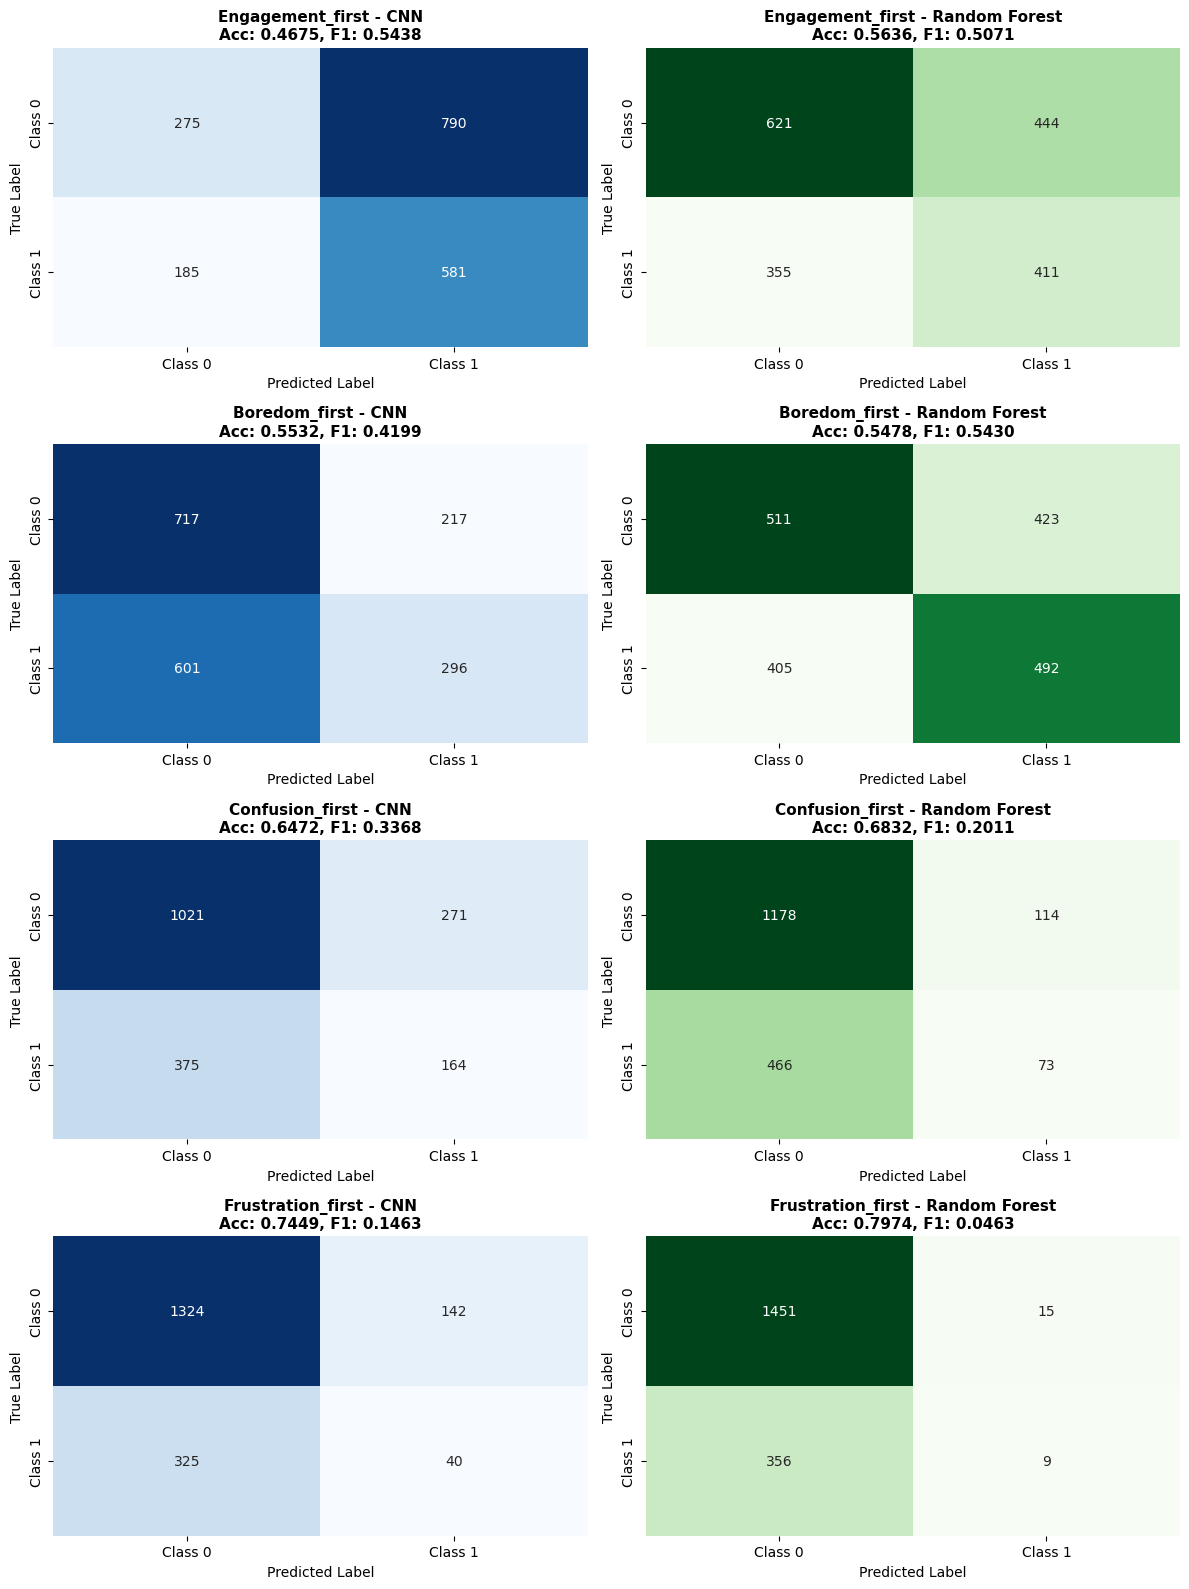

Confusion matrices saved to confusion_matrices.png


In [11]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(len(EMOTION_THRESHOLDS), 2, figsize=(12, len(EMOTION_THRESHOLDS)*4))
if len(EMOTION_THRESHOLDS) == 1:
    axes = axes.reshape(1, -1)

for idx, emotion in enumerate(EMOTION_THRESHOLDS.keys()):
    metrics = trained_models[emotion]['metrics']
    
    # CNN Confusion Matrix
    cnn_cm = metrics['CNN']['confusion_matrix']
    sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0], 
                cbar=False, xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    axes[idx, 0].set_title(f'{emotion} - CNN\nAcc: {metrics["CNN"]["accuracy"]:.4f}, F1: {metrics["CNN"]["f1"]:.4f}', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('True Label')
    axes[idx, 0].set_xlabel('Predicted Label')
    
    # Random Forest Confusion Matrix
    rf_cm = metrics['RandomForest']['confusion_matrix']
    sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx, 1],
                cbar=False, xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    axes[idx, 1].set_title(f'{emotion} - Random Forest\nAcc: {metrics["RandomForest"]["accuracy"]:.4f}, F1: {metrics["RandomForest"]["f1"]:.4f}', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel('True Label')
    axes[idx, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrices saved to confusion_matrices.png")

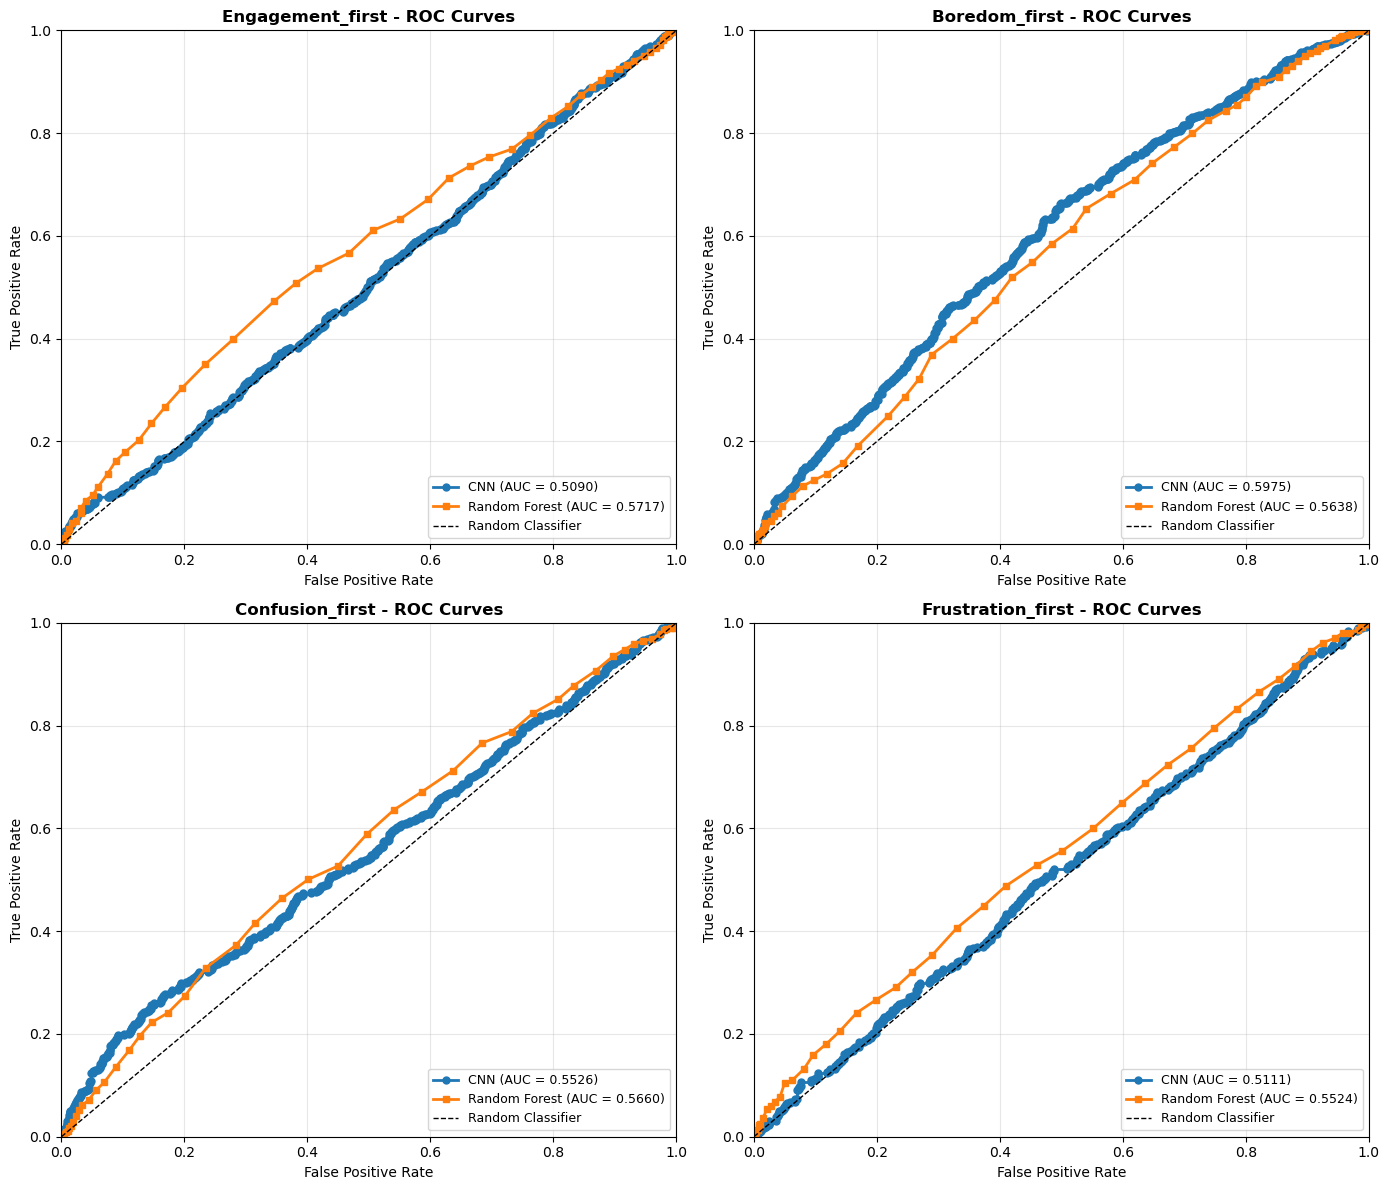

ROC curves saved to roc_curves.png


In [12]:
# ROC Curve Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

emotions_list = list(EMOTION_THRESHOLDS.keys())

for idx, emotion in enumerate(emotions_list):
    metrics = trained_models[emotion]['metrics']
    y_test_emotion = emotion_data[emotion]['y_test']
    
    # CNN ROC Curve
    cnn_fpr, cnn_tpr, _ = roc_curve(y_test_emotion, metrics['CNN']['predictions_proba'])
    cnn_auc = metrics['CNN']['roc_auc']
    
    # Random Forest ROC Curve
    rf_fpr, rf_tpr, _ = roc_curve(y_test_emotion, metrics['RandomForest']['predictions_proba'])
    rf_auc = metrics['RandomForest']['roc_auc']
    
    ax = axes[idx]
    ax.plot(cnn_fpr, cnn_tpr, label=f'CNN (AUC = {cnn_auc:.4f})', linewidth=2, marker='o', markersize=5)
    ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})', linewidth=2, marker='s', markersize=5)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{emotion} - ROC Curves', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC curves saved to roc_curves.png")

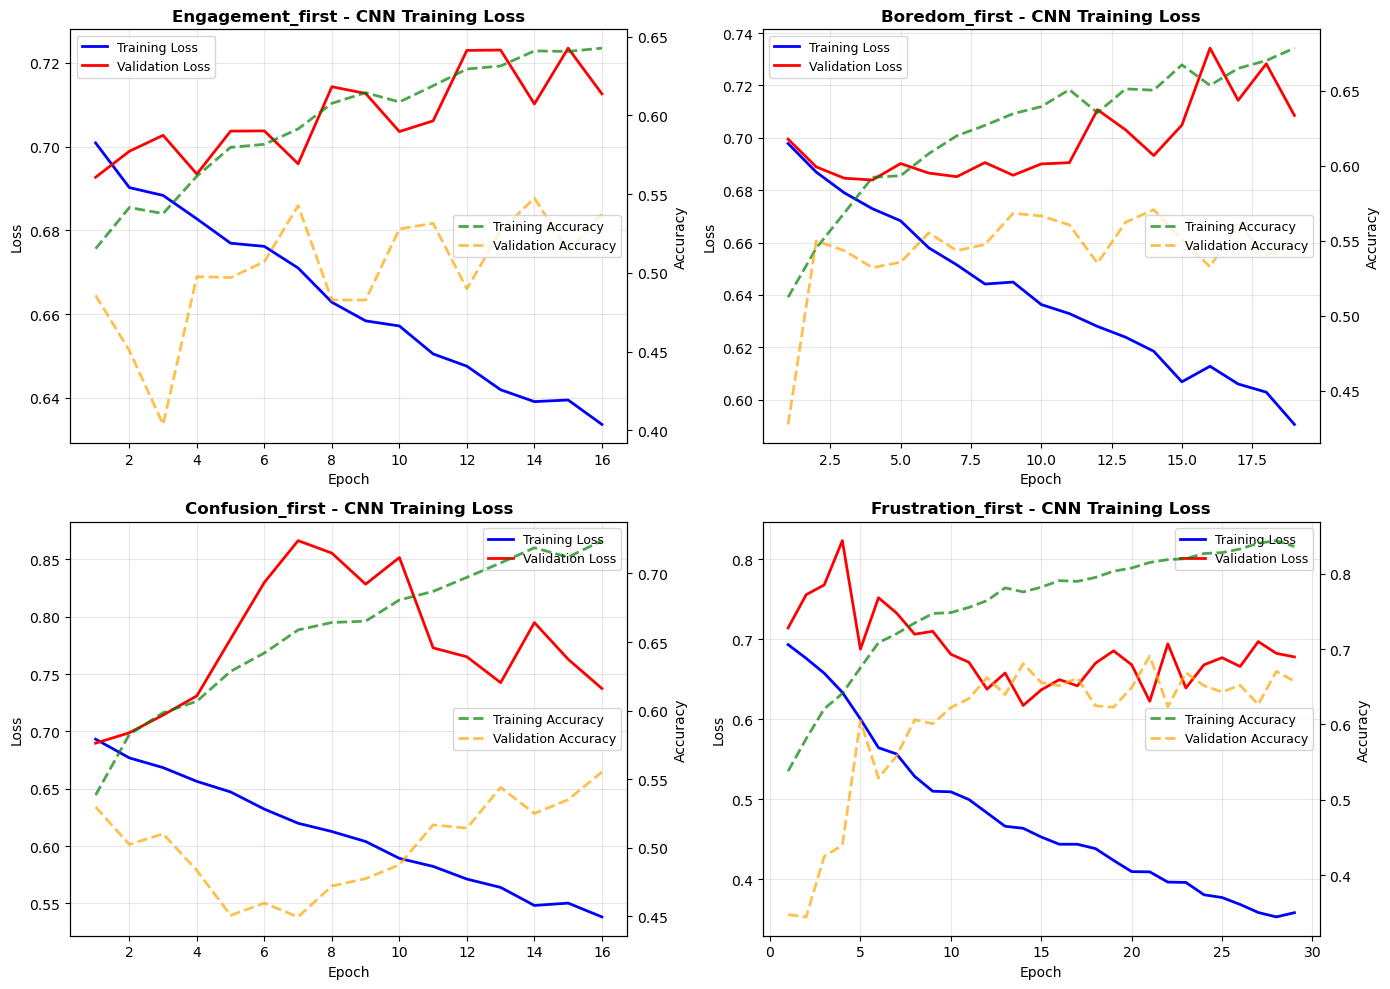

Training history saved to training_history.png


In [13]:
# CNN Training History Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, emotion in enumerate(emotions_list):
    history = trained_models[emotion]['cnn_history']
    ax = axes[idx]
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    ax.plot(epochs, history.history['loss'], 'b-', linewidth=2, label='Training Loss')
    ax.plot(epochs, history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'{emotion} - CNN Training Loss', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add secondary y-axis for accuracy
    ax2 = ax.twinx()
    ax2.plot(epochs, history.history['accuracy'], 'g--', linewidth=2, label='Training Accuracy', alpha=0.7)
    ax2.plot(epochs, history.history['val_accuracy'], 'orange', linestyle='--', linewidth=2, label='Validation Accuracy', alpha=0.7)
    ax2.set_ylabel('Accuracy', fontsize=10)
    ax2.legend(loc='center right', fontsize=9)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history saved to training_history.png")

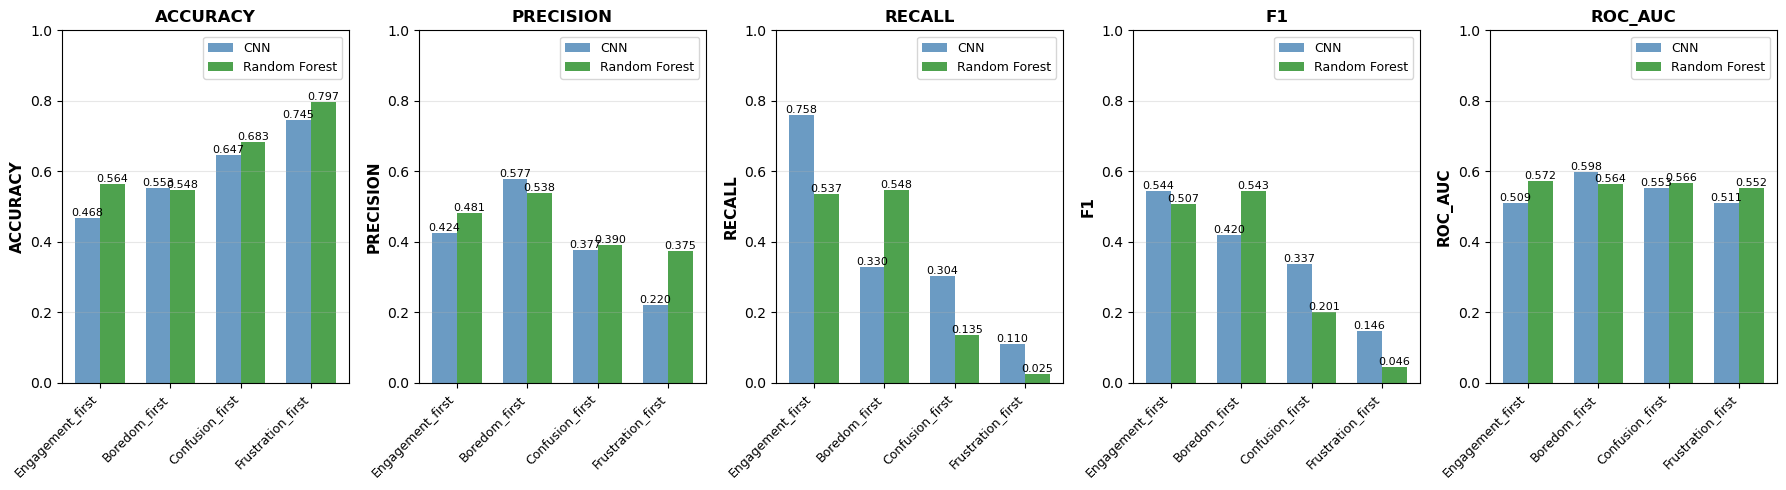

Metrics comparison saved to metrics_comparison.png


In [14]:
# Summary metrics comparison
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for metric_idx, metric in enumerate(metrics_names):
    ax = axes[metric_idx]
    
    # Prepare data for plotting
    emotions = results_df[results_df['model'] == 'CNN']['emotion'].values
    cnn_values = results_df[results_df['model'] == 'CNN'][metric].values
    rf_values = results_df[results_df['model'] == 'RandomForest'][metric].values
    
    x = np.arange(len(emotions))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cnn_values, width, label='CNN', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, rf_values, width, label='Random Forest', color='forestgreen', alpha=0.8)
    
    ax.set_ylabel(metric.upper(), fontsize=11, fontweight='bold')
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(emotions, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Metrics comparison saved to metrics_comparison.png")

In [15]:
# Final Summary Report
print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print("\n1. MODEL PERFORMANCE SUMMARY:")
print("-" * 80)
for emotion in EMOTION_THRESHOLDS.keys():
    print(f"\n{emotion}:")
    metrics = trained_models[emotion]['metrics']
    for model_name in ['CNN', 'RandomForest']:
        m = metrics[model_name]
        print(f"  {model_name:15} | Acc: {m['accuracy']:.4f} | Prec: {m['precision']:.4f} | Rec: {m['recall']:.4f} | F1: {m['f1']:.4f} | AUC: {m['roc_auc']:.4f}")

print("\n\n2. OVERALL STATISTICS:")
print("-" * 80)
cnn_results = results_df[results_df['model'] == 'CNN']
rf_results = results_df[results_df['model'] == 'RandomForest']

print(f"\nCNN Performance:")
print(f"  Mean Accuracy:  {cnn_results['accuracy'].mean():.4f} (±{cnn_results['accuracy'].std():.4f})")
print(f"  Mean Precision: {cnn_results['precision'].mean():.4f} (±{cnn_results['precision'].std():.4f})")
print(f"  Mean Recall:    {cnn_results['recall'].mean():.4f} (±{cnn_results['recall'].std():.4f})")
print(f"  Mean F1-Score:  {cnn_results['f1'].mean():.4f} (±{cnn_results['f1'].std():.4f})")
print(f"  Mean ROC-AUC:   {cnn_results['roc_auc'].mean():.4f} (±{cnn_results['roc_auc'].std():.4f})")

print(f"\nRandom Forest Performance:")
print(f"  Mean Accuracy:  {rf_results['accuracy'].mean():.4f} (±{rf_results['accuracy'].std():.4f})")
print(f"  Mean Precision: {rf_results['precision'].mean():.4f} (±{rf_results['precision'].std():.4f})")
print(f"  Mean Recall:    {rf_results['recall'].mean():.4f} (±{rf_results['recall'].std():.4f})")
print(f"  Mean F1-Score:  {rf_results['f1'].mean():.4f} (±{rf_results['f1'].std():.4f})")
print(f"  Mean ROC-AUC:   {rf_results['roc_auc'].mean():.4f} (±{rf_results['roc_auc'].std():.4f})")

print("\n\n3. EMOTION-WISE WINNER (Higher is better):")
print("-" * 80)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    cnn_avg = cnn_results[metric].mean()
    rf_avg = rf_results[metric].mean()
    winner = 'CNN' if cnn_avg > rf_avg else 'Random Forest'
    print(f"  {metric:12}: {winner:15} (CNN: {cnn_avg:.4f} vs RF: {rf_avg:.4f})")

print("\n\n4. OUTPUT FILES GENERATED:")
print("-" * 80)
print("  - confusion_matrices.png     : Confusion matrices for all emotions and models")
print("  - roc_curves.png             : ROC curves for all emotions and models")
print("  - training_history.png       : CNN training loss and accuracy curves")
print("  - metrics_comparison.png     : Bar charts comparing all metrics")

print("\n" + "="*80)


FINAL SUMMARY REPORT

1. MODEL PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------

Engagement_first:
  CNN             | Acc: 0.4675 | Prec: 0.4238 | Rec: 0.7585 | F1: 0.5438 | AUC: 0.5090
  RandomForest    | Acc: 0.5636 | Prec: 0.4807 | Rec: 0.5366 | F1: 0.5071 | AUC: 0.5717

Boredom_first:
  CNN             | Acc: 0.5532 | Prec: 0.5770 | Rec: 0.3300 | F1: 0.4199 | AUC: 0.5975
  RandomForest    | Acc: 0.5478 | Prec: 0.5377 | Rec: 0.5485 | F1: 0.5430 | AUC: 0.5638

Confusion_first:
  CNN             | Acc: 0.6472 | Prec: 0.3770 | Rec: 0.3043 | F1: 0.3368 | AUC: 0.5526
  RandomForest    | Acc: 0.6832 | Prec: 0.3904 | Rec: 0.1354 | F1: 0.2011 | AUC: 0.5660

Frustration_first:
  CNN             | Acc: 0.7449 | Prec: 0.2198 | Rec: 0.1096 | F1: 0.1463 | AUC: 0.5111
  RandomForest    | Acc: 0.7974 | Prec: 0.3750 | Rec: 0.0247 | F1: 0.0463 | AUC: 0.5524


2. OVERALL STATISTICS:
----------------------------------------------------------------